# Final Presentation: Airbnb Case Study

**Business Context:**

Airbnb hosts operate in a highly competitive market where pricing and positioning are critical for attracting guests. Understanding the factors that influence listing prices can help hosts optimize their strategies and improve booking performance. This project analyzes Airbnb listings in New York City to identify key drivers of pricing.

**Objectives and Key Questions:**

<div class="alert alert-success"> Identify the key factors influencing Airbnb listing prices in New York City in order to provide insights that help hosts optimize their pricing strategies and improve their competitiveness.
 <b></b></div>

1. How does location influence Airbnb listing prices in New York City?
2. Is there a relationship between the number of reviews and Airbnb listing prices?
3. How does the type of room (entire home, private room, or shared room) affect listing prices?



**Dataset Description:**
The dataset used in this project comes from Airbnb listing data for New York City, originally published on Kaggle. The dataset contains approximately 48,000 listings and 16 variables describing each Airbnb property.

**Main Variables**
Some of the most relevant variables used in this analysis include:
* **Price:**  Price per night for the listing (USD)
* **Neighbourhood_group:** Borough where the listing is located (Manhattan, Brooklyn, Queens, Bronx, Staten Island)
* **Neighbourhood:**  Specific neighborhood within the borough
* **Room_type:**  Type of accommodation (Entire home/apt, Private room, Shared room)
* **Minimum_nights:** Minimum number of nights required for booking
* **Number_of_reviews:**  Total number of reviews received
* **Reviews_per_month:** Average number of reviews per month
* **Availability_365:**  Number of days the listing is available during the year


**Methodology:**

This analysis is conducted using Python with the libraries Pandas, NumPy, Matplotlib, and Seaborn. The workflow includes data exploration, basic cleaning, and exploratory data analysis (EDA). Visualizations such as bar charts, boxplots, and scatter plots are used to identify patterns and relationships in the data.

This study uses a quantitative approach to analyze the main factors influencing Airbnb listing prices in New York City.

The analysis is based on existing data and combines different techniques to explore patterns and relationships between variables. 

Overall, this methodology is appropriate because it allows for a structured analysis of the data, helping uncover meaningful insights that can support more effective pricing decisions.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 50)

### Clean the Data

Before conducting the analysis, a data cleaning process was carried out to ensure the dataset is accurate, consistent, and suitable for further exploration. This stage focuses on identifying data types, correcting inconsistencies, handling missing values, and preparing key variables. Proper data cleaning is essential to improve the reliability of the results and to avoid potential errors during the analysis.

In [56]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [57]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

<div class="alert alert-warning">The variable last_review represents the date of the most recent review for each Airbnb listing. When the dataset was loaded, this column was stored as an object type, which means it was interpreted as text rather than a date. To ensure proper handling of temporal data, the column is converted to a datetime format. This allows for correct date-based analysis and ensures the variable is stored in an appropriate format for further exploration.</div>

In [58]:
df['last_review'] = pd.to_datetime(df['last_review'])
df.dtypes

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

<div class="alert alert-info"><b>Code 1.4</b> As part of the data cleaning process, we check for missing values.</div>

In [59]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

<div class="alert alert-info"><b>Code 1.5</b> Missing values in some columns are replaced with 0.</div>

In [60]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

<div class="alert alert-info"><b>Code 1.6</b> Consider the price is a key variable required for the analysis, rows with missing values are removed.</div>

In [61]:
df = df.dropna(subset=['price'])

<div class="alert alert-info"><b>Code 1.6</b> Check if there are duplicate rows in the dataset that may need to be removed during the data cleaning process.</div>

In [62]:
df.duplicated().sum()

np.int64(0)

### 1. How does location influence Airbnb listing prices in New York City?

To understand how location influences Airbnb listing prices, we analyze the average price across the different neighbourhoods of New York City. Since demand, tourism activity, and accessibility vary by area, location is expected to be an important factor affecting pricing.

<div class="alert alert-success">
<b>Price Comparison Across Neighbourhood</b>

We compare listing prices across neighbouthood such as Manhattan, Brooklyn, Queens, the Bronx, and Staten Island. By examining the distribution of prices by location, we can identify which areas tend to have higher or lower Airbnb prices.

</div>

This analysis helps identify pricing patterns by location and provides insights into which boroughs are associated with higher-value listings.
<div class="alert alert-info"> The results of this analysis highlight how location significantly influences Airbnb pricing in New York City. Neighbouthoods with higher tourism demand and central locations, such as Manhattan and parts of Brooklyn, tend to have higher average listing prices compared to areas like the Bronx, Queens, or Staten Island. This suggests that proximity to major attractions, business districts, and transportation hubs plays an important role in determining listing value.</div>

In [63]:
price_by_neighbourhood = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
price_by_neighbourhood

neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

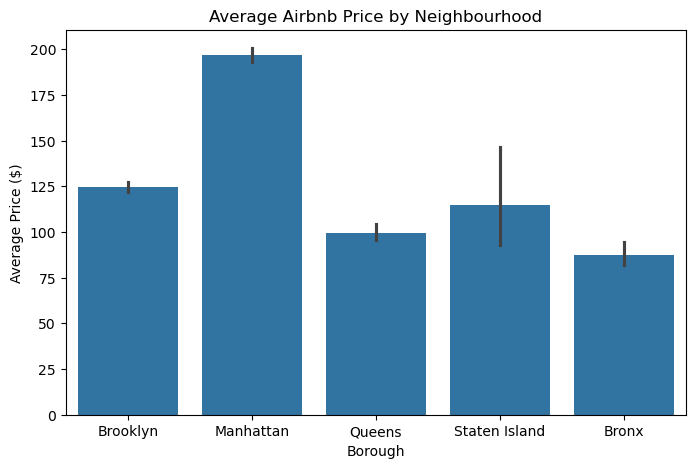

In [64]:
plt.figure(figsize=(8,5))
sns.barplot(x='neighbourhood_group', y='price', data=df)

plt.title("Average Airbnb Price by Neighbourhood")
plt.xlabel("Borough")
plt.ylabel("Average Price ($)")
plt.show()

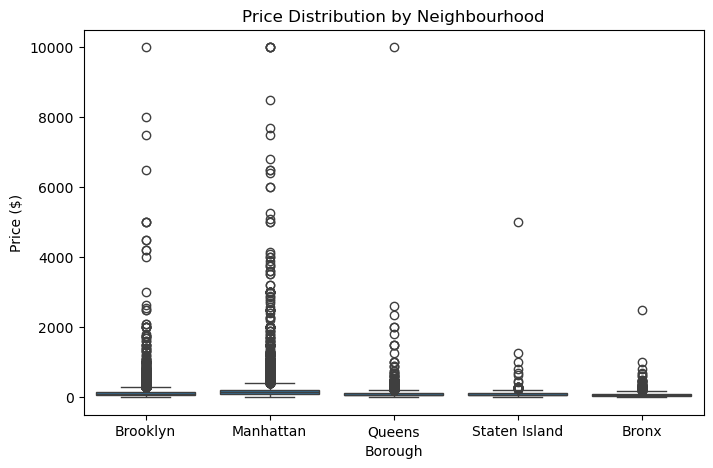

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=df)

plt.title("Price Distribution by Neighbourhood")
plt.xlabel("Borough")
plt.ylabel("Price ($)")
plt.show()


**Conclusion:**

The analysis shows that location has a strong influence on Airbnb listing prices in New York City. Among the boroughs, Manhattan has the highest average listing price followed by Brooklyn. In contrast, Queens, Staten Island, and the Bronx have noticeably lower average prices, with the Bronx showing the lowest average price.

<div class="alert alert-success">
<b>Luxury Options Increase the Price Ranges</b>

The boxplot also reveals that Manhattan and Brooklyn have a wider price distribution and more extreme outliers, indicating the presence of many high-end or luxury listings in these areas. Meanwhile, the other boroughs show lower and more concentrated price ranges, suggesting more affordable accommodation options.

</div>

These results suggest that centrality, tourism demand, and proximity to major attractions and business districts play a key role in determining Airbnb prices.



### 2. Impact of Room Type on Airbnb Prices

Room type is expected to be an important factor influencing Airbnb listing prices. Entire homes usually provide more privacy and space, which may lead to higher prices compared to private or shared rooms.

To better understand this relationship, we analyze how listing prices vary across different room types available on Airbnb: entire home/apartment, private room, and shared room.

<div class="alert alert-success">

**Room Type and Price Comparison**

In this section, we analyze how Airbnb listing prices vary depending on the type of accommodation offered. Listings on Airbnb can be categorized into three main room types: entire home/apartment, private room, and shared room.

By comparing the average price across these categories, we can better understand how the level of privacy and space provided by the accommodation affects listing prices.

</div>

In [66]:
price_by_room = df.groupby('room_type')['price'].mean().round(2).sort_values(ascending=False)

price_by_room

room_type
Entire home/apt    211.79
Private room        89.78
Shared room         70.13
Name: price, dtype: float64

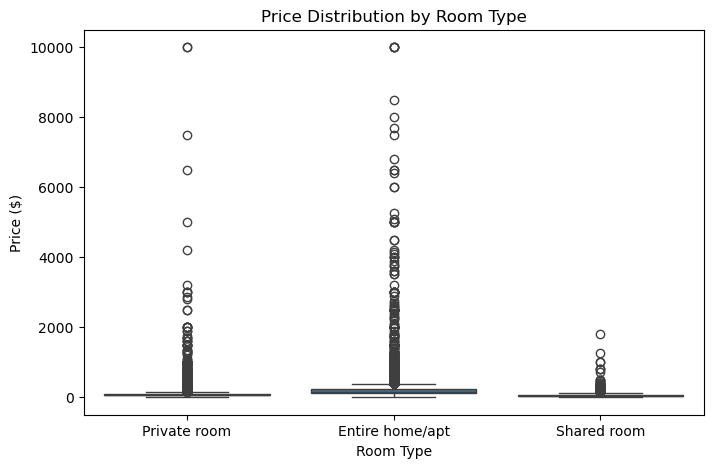

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(x='room_type', y='price', data=df)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")

plt.show()

<div class="alert alert-info">

The analysis shows clear differences in pricing depending on the type of room offered. Listings for entire homes or apartments have the highest average price, with an average of approximately **$211.79** per night. This is expected because entire homes provide guests with full privacy, more space, and additional amenities.

Private rooms have a significantly lower average price of about **$89.78**, making them a more affordable option for travelers who still prefer having their own private space within a shared property.

Shared rooms have the lowest average price, around **$70.13**, as guests share the accommodation with others, which reduces privacy and comfort.

The boxplot also shows that entire homes have a wider price distribution and more extreme values, suggesting the presence of high-end or luxury listings in this category.

</div>

Overall, the analysis indicates that room type is a significant factor influencing Airbnb listing prices in New York City. Entire homes and apartments tend to command higher prices due to the additional privacy, space, and amenities they offer.

In contrast, private and shared rooms are generally more affordable options and cater to budget-conscious travelers.

These findings suggest that accommodation type plays an important role in determining how listings are priced on the Airbnb platform.

**Managerial Insights**

These results suggest that Airbnb hosts should carefully consider the type of accommodation they offer when setting prices.

Hosts offering entire homes or apartments can position their listings as premium accommodations and justify higher prices due to increased privacy and comfort.

Meanwhile, hosts renting private or shared rooms may benefit from competitive pricing strategies that appeal to budget travelers, students, and short-term visitors.

## 3. Is there a relationship between the number of reviews and Airbnb listing prices?

To understand whether listing popularity influences Airbnb prices, we analyze the relationship between the **number of reviews** and Airbnb listing prices. Since listings with more reviews are typically booked more frequently and may attract greater visibility on the platform, popularity could potentially influence pricing patterns.

<div style="background-color:#d4edda; padding:15px; border-radius:5px">

**Price Comparison Based on Number of Reviews**

We examine how Airbnb listing prices vary according to the number of reviews received by each listing. By visualizing the distribution of prices across listings with different review counts, we can identify whether popularity is associated with higher or lower listing prices.

</div>

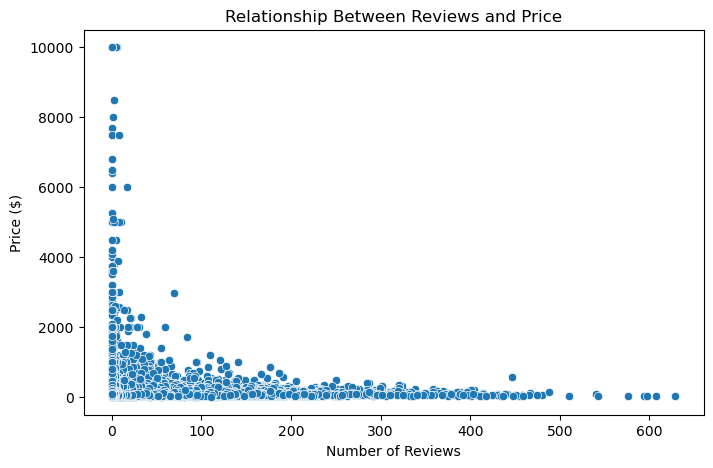

In [68]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='number_of_reviews', y='price', data=df)

plt.title("Relationship Between Reviews and Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.show()

<div style="background-color:#d1ecf1; padding:15px; border-radius:5px">

The scatterplot illustrates the relationship between the **number of reviews** and Airbnb listing prices. Most listings with a high number of reviews tend to have relatively moderate or lower prices, while listings with very high prices often appear among those with fewer reviews.

This pattern suggests that more affordable listings may attract more bookings over time, which leads to a greater number of reviews. In contrast, higher-priced listings may receive fewer bookings and therefore accumulate fewer reviews.

Overall, the visualization indicates that the relationship between the number of reviews and listing prices is relatively weak.

</div>

</div>

These results suggest that listing popularity, measured by the number of reviews, does not strongly determine Airbnb prices. Instead, other factors such as location or accommodation type may have a greater influence on listing prices.

## Conclusions and Recommendations:

This section consolidates the main analytical findings and translates them into strategic recommendations for Airbnb hosts. The results highlight how pricing is influenced by key factors such as location, accommodation type, and distinct market segments.

By leveraging these insights, hosts can adopt more informed and targeted pricing strategies, aligning their offerings with market demand and competitive positioning.

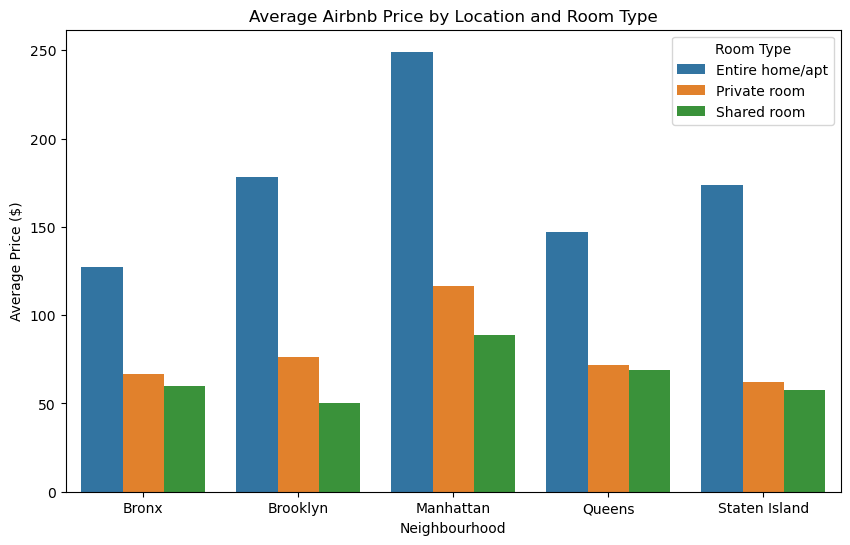

In [70]:
price_location_room = df.groupby(['neighbourhood_group','room_type'])['price'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='neighbourhood_group', y='price', hue='room_type', data=price_location_room)

plt.title("Average Airbnb Price by Location and Room Type")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price ($)")
plt.legend(title="Room Type")

plt.show()

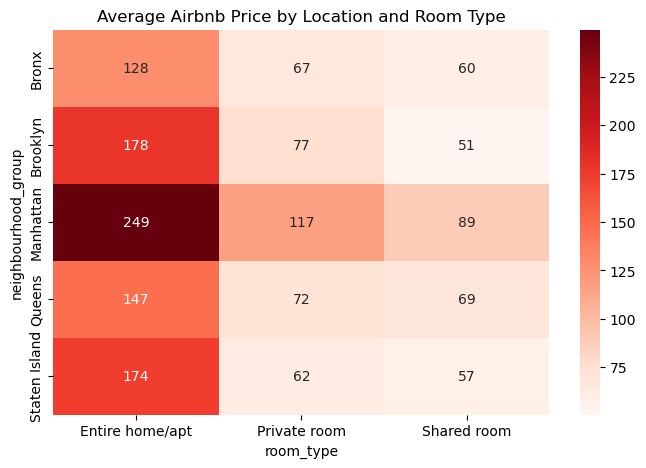

In [69]:
pivot = df.pivot_table(values='price',
                       index='neighbourhood_group',
                       columns='room_type',
                       aggfunc='mean')

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Reds")

plt.title("Average Airbnb Price by Location and Room Type")

plt.show()

<Axes: xlabel='price', ylabel='number_of_reviews'>

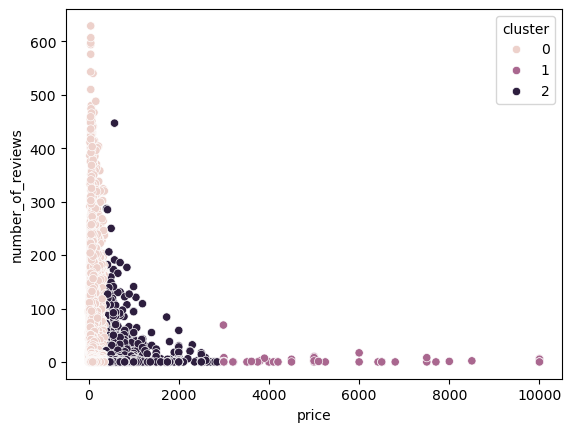

In [71]:
df_cluster = df[['price', 'minimum_nights', 'number_of_reviews']].dropna().copy()

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(df_cluster)

sns.scatterplot(x='price', y='number_of_reviews', hue='cluster', data=df_cluster)

The analysis provides several **Insights** that can help Airbnb hosts optimize their pricing strategie:.

**1)** **Location** plays a key role in determining prices. Listings in **Manhattan** and **Brooklyn** have significantly higher average prices than those in Queens, Staten Island, and the Bronx. This suggests that hosts in central areas can position their properties as premium listings due to their proximity to major attractions and transportation hubs.

**2)** **Accommodation** type strongly affects pricing. Entire homes or apartments have the highest average price ($211.79) while private rooms ($89.78) and shared rooms ($70.13) are considerably cheaper. Hosts offering entire properties can therefore adopt premium pricing strategies, while private or shared rooms may benefit from more competitive pricing to attract budget travelers.

**3)** The clustering analysis reveals three distinct segments in the Airbnb market based on price and number of **reviews**.

* **First cluster:** Represents low-priced listings with a high number of reviews, indicating that affordability is associated with higher demand and booking frequency. 

* **Second cluster:** Includes moderately priced listings with a balanced number of reviews, representing the core market segment. 

* **Third cluster:** Consists of high-priced listings with relatively few reviews, suggesting premium or luxury properties with lower booking frequency.

These findings highlight that the Airbnb market is segmented, and different pricing strategies apply to each group:

**1)Lower-priced:** Tend to focus on volume and visibility

**2)Higher-priced** Adopt a premium positioning strategy.


<div style="background-color:#d4edda; padding:15px; border-radius:5px">

**Based on these findings, several recommendations can be made**

**1)** **Adjust pricing according to location:** Hosts in Manhattan and Brooklyn can justify higher prices, while listings in outer boroughs may require more competitive pricing.

**2)** **Leverage accommodation type:** Entire homes should emphasize privacy and comfort to support higher prices, while private and shared rooms should highlight affordability.

**3)** **Use strategic pricing to gain reviews:** New listings may benefit from slightly lower initial prices to attract bookings and increase visibility on the platform.

</div>

## Next Steps:

To further support long-term strategic decision making, future analyses could explore additional factors that may influence Airbnb pricing:
* **Demand and seasonality:** Analyze how prices fluctuate throughout the year depending on tourism trends and seasonal demand.
* **Host characteristics:** Investigate whether host experience, response rates, or number of listings affect pricing and performance.
* **Amenities and property features:** Examine how elements such as number of bedrooms, amenities, or property size impact listing prices.
* **Neighborhood-level dynamics:** Conduct a more detailed analysis within boroughs to identify micro-locations where pricing patterns differ.